In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc

In [2]:
# ============================
# LOAD DATASET
# ============================

df = pd.read_csv("loan_approval.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:\n", df.head())
print("\nData Types:\n", df.dtypes)

Dataset Shape: (30, 7)

First 5 Rows:
    Age  Income  CreditScore  LoanAmount  LoanTerm  ExistingLoans  LoanApproved
0   25   30000          620      200000        20              1             0
1   35   55000          680      250000        25              1             1
2   45   75000          720      300000        30              0             1
3   28   40000          650      180000        20              2             0
4   50   90000          780      350000        30              0             1

Data Types:
 Age              int64
Income           int64
CreditScore      int64
LoanAmount       int64
LoanTerm         int64
ExistingLoans    int64
LoanApproved     int64
dtype: object


In [3]:
# ============================
# PART A – DATA UNDERSTANDING
# ============================

# Identify Numerical & Categorical Features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print("\nNumerical Features:", numerical_features)
print("Categorical Features:", categorical_features)


Numerical Features: ['Age', 'Income', 'CreditScore', 'LoanAmount', 'LoanTerm', 'ExistingLoans', 'LoanApproved']
Categorical Features: []


In [4]:
# Assume target column is 'LoanApproved'
target_column = "LoanApproved"


Correlation of CreditScore with LoanApproved:
              CreditScore  LoanApproved
CreditScore       1.00000       0.78634
LoanApproved      0.78634       1.00000


<Figure size 640x480 with 0 Axes>

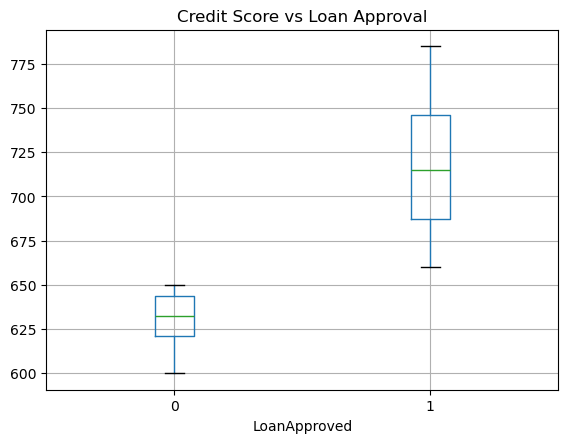

In [5]:
# ----------------------------
# Check if CreditScore alone predicts approval
# ----------------------------
if "CreditScore" in df.columns:
    print("\nCorrelation of CreditScore with LoanApproved:")
    print(df[["CreditScore", target_column]].corr())

    plt.figure()
    df.boxplot(column="CreditScore", by=target_column)
    plt.title("Credit Score vs Loan Approval")
    plt.suptitle("")
    plt.show()

In [6]:
# ============================
# DATA PREPROCESSING
# ============================

# Encode categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop(target_column, axis=1)
y = df_encoded[target_column]

In [7]:
X

,Age,Income,CreditScore,LoanAmount,LoanTerm,ExistingLoans
0,25,30000,620,200000,20,1
1,35,55000,680,250000,25,1
2,45,75000,720,300000,30,0
3,28,40000,650,180000,20,2
4,50,90000,780,350000,30,0
5,32,48000,660,220000,25,1
6,41,82000,740,320000,30,0
7,29,42000,630,200000,20,2
8,38,60000,700,270000,25,1
9,48,88000,760,340000,30,0


In [8]:
y

0     0
1     1
2     1
3     0
4     1
5     1
6     1
7     0
8     1
9     1
10    0
11    1
12    1
13    0
14    1
15    0
16    1
17    1
18    0
19    1
20    1
21    0
22    1
23    1
24    1
25    0
26    1
27    0
28    1
29    1
Name: LoanApproved, dtype: int64

In [9]:
# ============================
# PART B – MODEL DEVELOPMENT
# ============================

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [10]:
# Standard Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
# Train Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [12]:
# ============================
# PART C – EVALUATION
# ============================

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nModel Performance")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)


Model Performance
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0



Confusion Matrix:
 [[2 0]
 [0 7]]


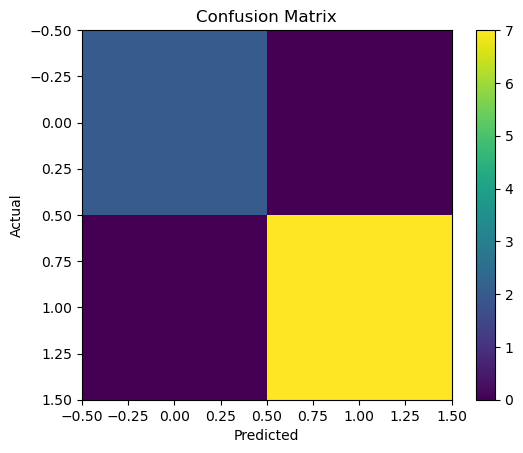

In [13]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()


In [14]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 1.0


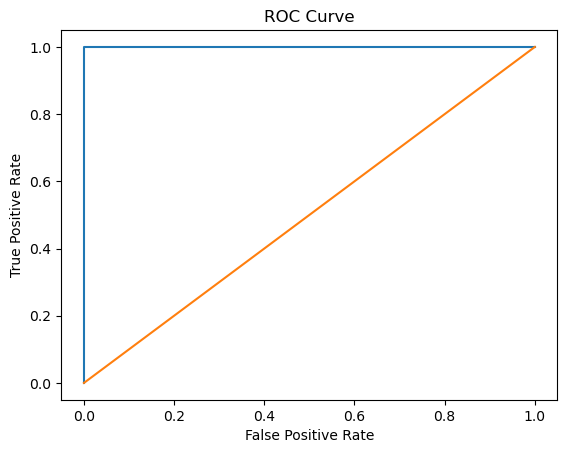

In [15]:
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [16]:
# ============================
# PART D – MODEL INTERPRETATION
# ============================

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0],
    "Odds_Ratio": np.exp(model.coef_[0])
}).sort_values(by="Coefficient", ascending=False)

In [17]:
print("\nFeature Impact:")
print(coefficients)


Feature Impact:
         Feature  Coefficient  Odds_Ratio
4       LoanTerm     1.027447    2.793923
2    CreditScore     0.615416    1.850426
0            Age     0.606584    1.834156
3     LoanAmount     0.548387    1.730460
1         Income     0.545975    1.726290
5  ExistingLoans    -0.895654    0.408340


In [18]:
# CreditScore Interpretation
if "CreditScore" in coefficients["Feature"].values:
    credit_odds = coefficients[coefficients["Feature"]=="CreditScore"]["Odds_Ratio"].values[0]
    print("\nImpact of CreditScore:")
    print("Odds Ratio:", credit_odds)
    print("Each unit increase multiplies approval odds by", credit_odds)


Impact of CreditScore:
Odds Ratio: 1.85042583803166
Each unit increase multiplies approval odds by 1.85042583803166
